# 국가별 음주 데이터 분석

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
# windows용 한글 폰트 오류 해결
from matplotlib import font_manager, rc
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = font_manager.FontProperties(fname = font_path).get_name()
rc('font', family=font_name)

In [2]:
drinks = pd.read_csv("./data/csv/drinks.csv")

In [3]:
drinks.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF


In [4]:
drinks.tail()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
188,Venezuela,333,100,3,7.7,SA
189,Vietnam,111,2,1,2.0,AS
190,Yemen,6,0,0,0.1,AS
191,Zambia,32,19,4,2.5,AF
192,Zimbabwe,64,18,4,4.7,AF


In [5]:
# 데이터의 행과 열 파악
drinks.shape

(193, 6)

In [6]:
drinks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       193 non-null    object 
 1   beer_servings                 193 non-null    int64  
 2   spirit_servings               193 non-null    int64  
 3   wine_servings                 193 non-null    int64  
 4   total_litres_of_pure_alcohol  193 non-null    float64
 5   continent                     170 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.2+ KB


In [7]:
drinks.columns

Index(['country', 'beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol', 'continent'],
      dtype='object')

In [15]:
drinks.dtypes

country                          object
beer_servings                     int64
spirit_servings                   int64
wine_servings                     int64
total_litres_of_pure_alcohol    float64
continent                        object
dtype: object

- 데이터 구조
    - country : 국가명
    - beer_servings : 맥주 주문 수
    - spirit_servings : spirit 주문 수
    - wine_servings : wine 주문 수
    - total_litres_of_pure_alcohol : 총 마신 음주 양
    - continent : 대륙 (AS, EU 등)

In [8]:
drinks.describe()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,193.000000,193.000000,193.000000
mean,106.160622,80.994819,49.450777,4.717098
std,101.143103,88.284312,79.697598,3.773298
min,0.000000,0.000000,0.000000,0.000000
25%,20.000000,4.000000,1.000000,1.300000
50%,76.000000,56.000000,8.000000,4.200000
75%,188.000000,128.000000,59.000000,7.200000
max,376.000000,438.000000,370.000000,14.400000


- 평균 beer_servings는 약 106
- 평균 spirit_servings는 약 80
- 평균 wine_servings는 약 49
- 평균 total_liters_of_pure_alcohol은 약 4.7

In [9]:
drinks.describe(include = "all")

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
count,193,193.000000,193.000000,193.000000,193.000000,170
unique,193,NaN,NaN,NaN,NaN,5
top,Afghanistan,NaN,NaN,NaN,NaN,AF
freq,1,NaN,NaN,NaN,NaN,53
mean,NaN,106.160622,80.994819,49.450777,4.717098,NaN
std,NaN,101.143103,88.284312,79.697598,3.773298,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,20.000000,4.000000,1.000000,1.300000,NaN
50%,NaN,76.000000,56.000000,8.000000,4.200000,NaN
75%,NaN,188.000000,128.000000,59.000000,7.200000,NaN


In [11]:
# 데이터 결측치 시각화
import missingno as msno

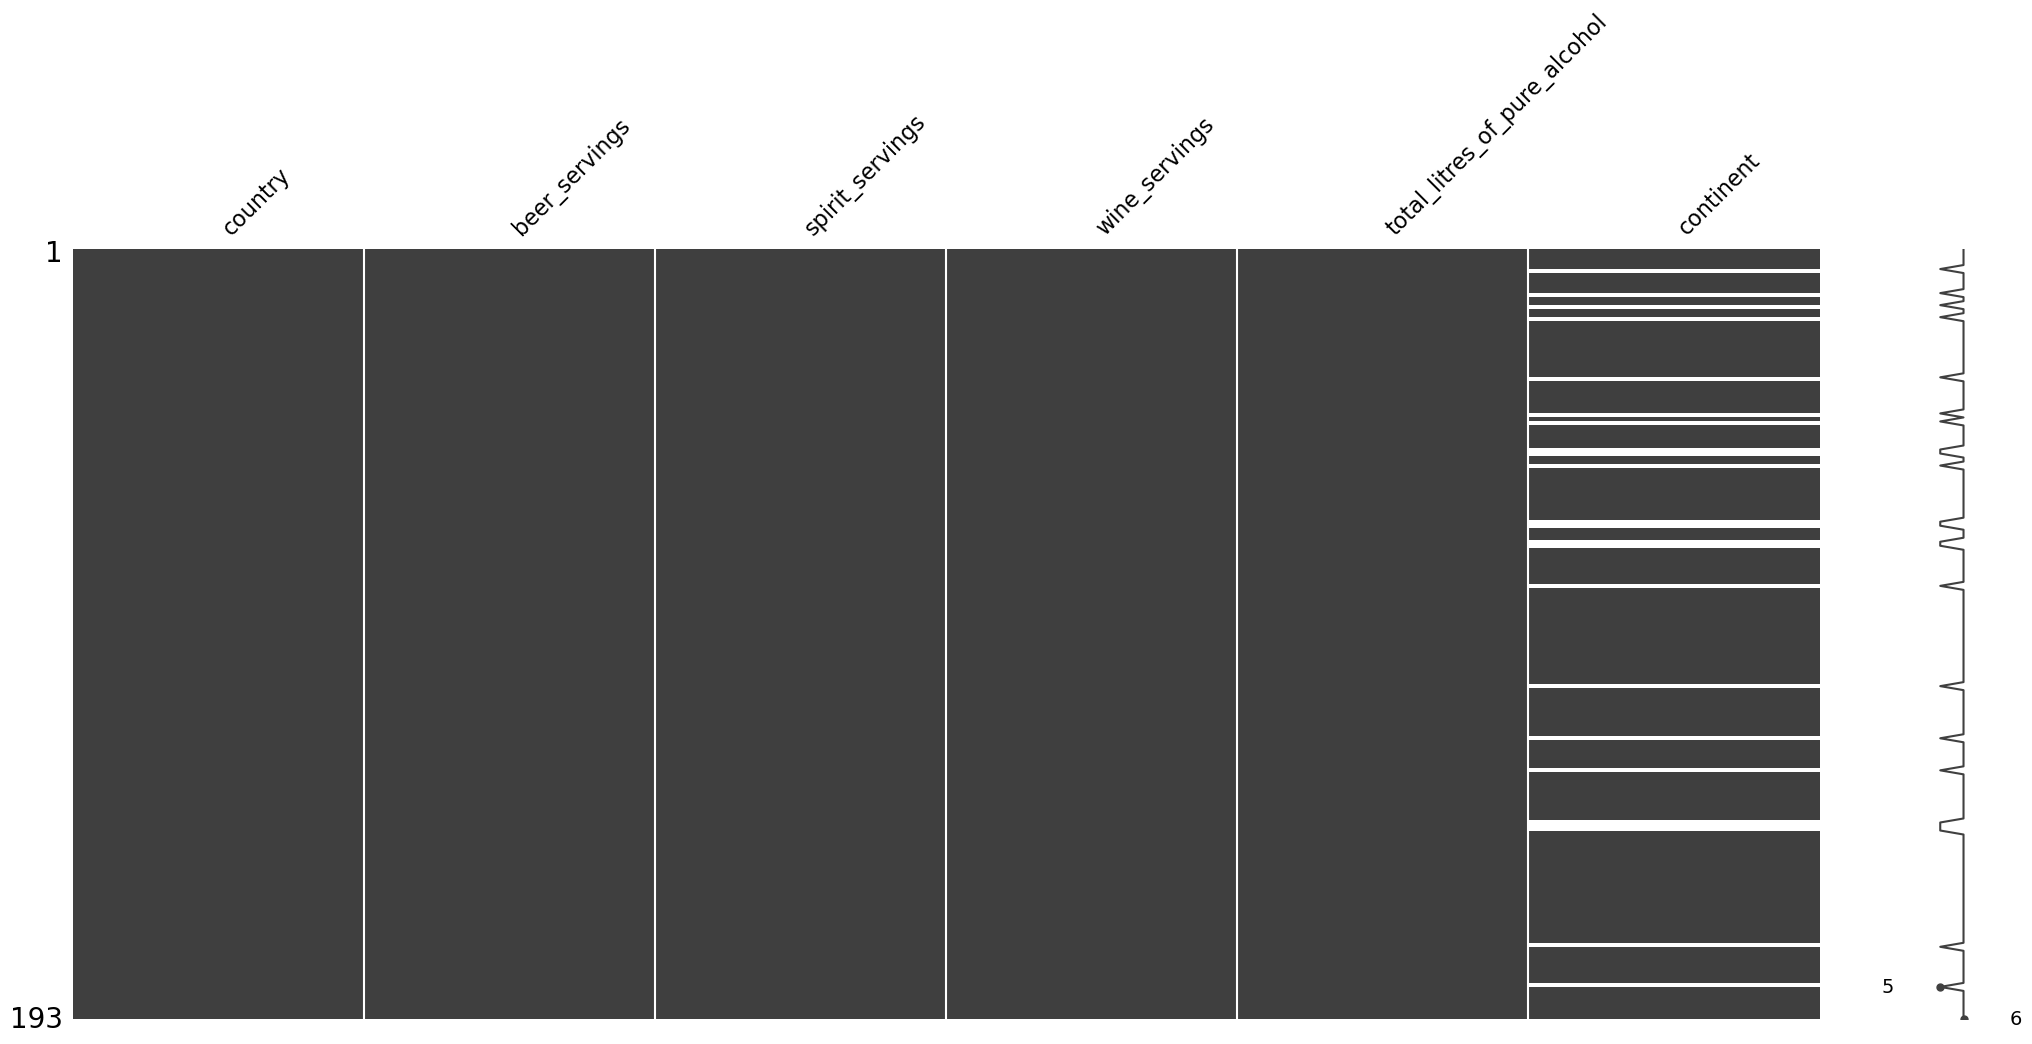

In [12]:
msno.matrix(drinks)

plt.show()

- continent에 결측치가 존재함을 확인할 수 있음
- 나머지 열에는 결측치가 존재하지 않음을 확인할 수 있음

In [13]:
drinks.isna().sum()

country                          0
beer_servings                    0
spirit_servings                  0
wine_servings                    0
total_litres_of_pure_alcohol     0
continent                       23
dtype: int64

In [16]:
# 범주형 데이터의 데이터 종류 수 파악하기
print(drinks["country"].nunique())
print(drinks["continent"].nunique())

193
5


## 데이터 속성 탐색

### 범주형 변수의 상세 확인

In [17]:
print(drinks["continent"].value_counts())

continent
AF    53
EU    45
AS    44
OC    16
SA    12
Name: count, dtype: int64


In [18]:
# 결측치가 있었기 때문에 결측치를 포함하여 빈도 확인
print(drinks["continent"].value_counts(dropna = False))

continent
AF     53
EU     45
AS     44
NaN    23
OC     16
SA     12
Name: count, dtype: int64


### 수치형 변수의 상관관계 확인

In [21]:
# 수치형 컬럼들만 선택
numeric_cols = ["beer_servings", "spirit_servings", "wine_servings", "total_litres_of_pure_alcohol"]
numeric_df = drinks[numeric_cols]

In [22]:
numeric_df.head()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,0,0,0,0.0
1,89,132,54,4.9
2,25,0,14,0.7
3,245,138,312,12.4
4,217,57,45,5.9


In [23]:
# 피어슨 상관계수 계산
correlation = numeric_df.corr()
correlation

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
beer_servings,1.000000,0.458819,0.527172,0.835839
spirit_servings,0.458819,1.000000,0.194797,0.654968
wine_servings,0.527172,0.194797,1.000000,0.667598
total_litres_of_pure_alcohol,0.835839,0.654968,0.667598,1.000000


- beer_servings와 total_litres_of_pure_alcohol의 상관계수 : 0.835839
    - 매우 강한 양의 상관관계
    - 맥주를 많이 마시는 나라일수록 전체 알코올 소비량도 매우 높다는 의미
    - 총 알코올 소비량에 가장 큰 영향을 주는 주종이 맥주

- wine_servings와 total_litres_of_pure_alcohol의 상관계수 : 0.667598
    - 비교적 강한 양의 상관관계
    - 와인 소비량 역시 총 알코올 소비량과 깊은 관련

- spirit_servings와 total_litres_of_pure_alcohol의 상관계수 : 0.654968
    - 비교적 강한 양의 상관관계
    - spirit 소비량 역시 총 알코올 소비량과 깊은 관련

- 주종 간의 상관관계
    - beer & wine : 0.527172로 어느 정도 연관성 존재
    - beer & spirit : 0.458819로 중간 정도의 연관성
    - spirit & wine : 0.194797로 상관계수가 가장 작으며 두 주종 사이에는 뚜렷한 연관성 적음

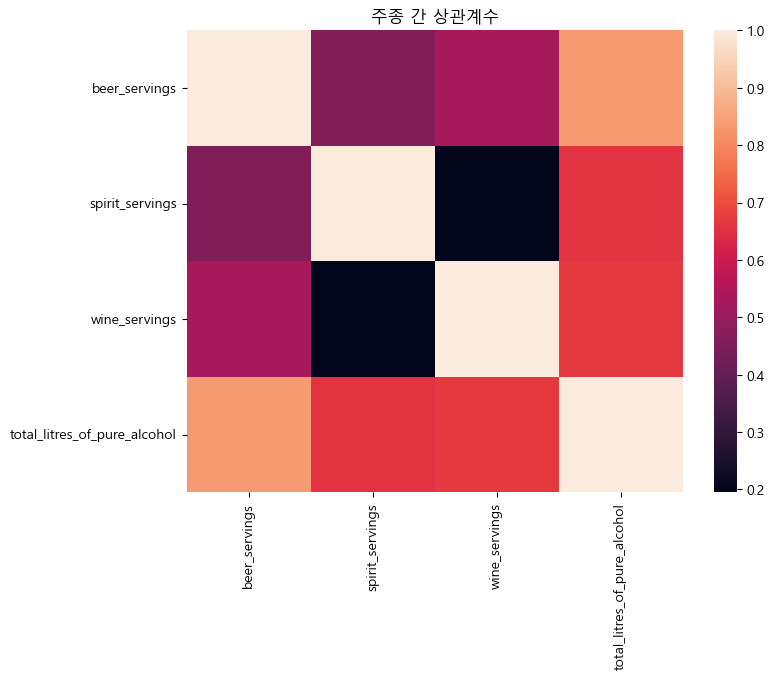

In [26]:
# 상관계수 시각화
plt.figure(figsize = (8, 6))

sns.heatmap(correlation)

plt.title("주종 간 상관계수")

plt.show()

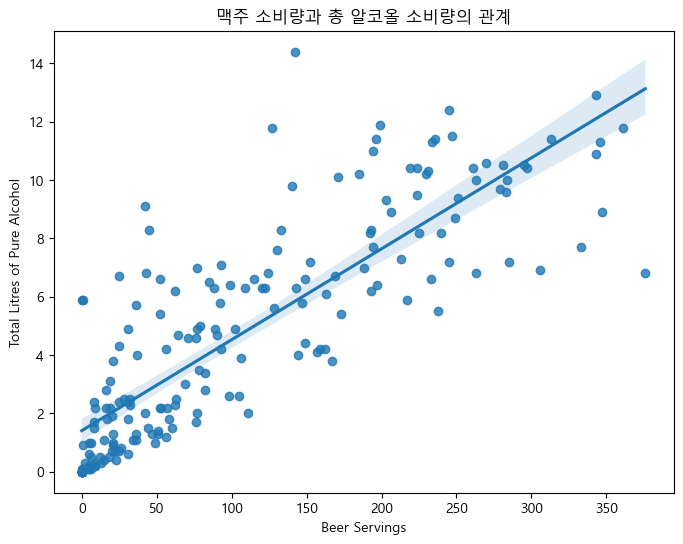

In [28]:
plt.figure(figsize=(8, 6))

sns.regplot(x='beer_servings', y='total_litres_of_pure_alcohol', data=drinks)

plt.title('맥주 소비량과 총 알코올 소비량의 관계')
plt.xlabel('Beer Servings')
plt.ylabel('Total Litres of Pure Alcohol')

plt.show()

## 데이터 전처리

In [29]:
# continent 컬럼의 결측치를 문자열 NA로 채우기
drinks["continent"] = drinks["continent"].fillna("NA")

In [30]:
print(drinks.isna().sum())

country                         0
beer_servings                   0
spirit_servings                 0
wine_servings                   0
total_litres_of_pure_alcohol    0
continent                       0
dtype: int64


## 추가 데이터 탐색

### 대륙별 평균 소비량 확인

In [31]:
continent_mean = drinks.groupby("continent")[numeric_cols].mean()

In [32]:
continent_mean

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
continent,,,,
AF,61.471698,16.339623,16.264151,3.007547
AS,37.045455,60.840909,9.068182,2.170455
EU,193.777778,132.555556,142.222222,8.617778
NA,145.434783,165.739130,24.521739,5.995652
OC,89.687500,58.437500,35.625000,3.381250
SA,175.083333,114.750000,62.416667,6.308333


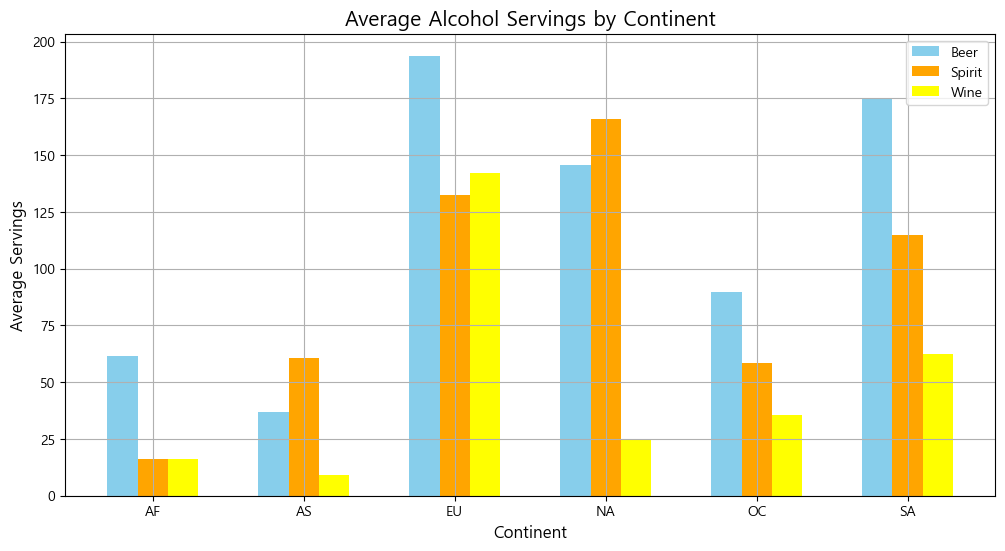

In [39]:
# 대륙별 평균 소비량 시각화
plt.figure(figsize = (12, 6))

continents = continent_mean.index
group_n = len(continents)

index = np.arange(group_n)

plt.bar(index, continent_mean['beer_servings'], 0.2,  label='Beer', color='skyblue')
plt.bar(index + 0.2, continent_mean['spirit_servings'], 0.2, label='Spirit', color='orange')
plt.bar(index + 0.4, continent_mean['wine_servings'], 0.2, label='Wine', color='yellow')

plt.title('Average Alcohol Servings by Continent', fontsize=15)
plt.xlabel('Continent', fontsize=12)
plt.ylabel('Average Servings', fontsize=12)

plt.xticks(index + 0.2, continents)

plt.legend()
plt.grid()

plt.show()

#### 해석

1. AF에서는 Bear 평균 주종 소비량이 가장 높고 Spirit과 Wine은 비슷하다
2. AS에서는 Spirit 평균 주종 소비량이 가장 높고 Bear가 그 다음이며 Wine 소비량이 가장 적다
3. EU에서는 전체 평균 주종 소비량이 가장 높은 편이며 Bear -> Wine -> Spirit 순서이다
    - Beer과 Wine의 주종 평균 소비량이 가장 높다
4. NA(결측치)에서는 전체 평균 주종 소비량이 높은 편이며 Spirit -> Bear -> Wine 순서이다
    - Spirit 주종 평균 소비량이 가장 높다
5. OC에서는 Beer -> Spirit -> Wine 순서
6. SA 역시 전체 평균 주종 소비량이 높은 편이며 Beer -> Spirit -> Wine 순서
7. 전체적으로 봤을 때 Beer -> Spirit -> Wine 순으로 많이 먹고 Wine은 거의 먹지 않는다는 것으로 예측할 수 있다.

### 전 세계 알코올 소비량 Top 10 국가 확인

In [40]:
drinks_sorted = drinks.sort_values("total_litres_of_pure_alcohol", ascending = False)

In [43]:
drinks_top10 = drinks_sorted.head(10)

In [44]:
drinks_top10

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
15,Belarus,142,373,42,14.4,EU
98,Lithuania,343,244,56,12.9,EU
3,Andorra,245,138,312,12.4,EU
68,Grenada,199,438,28,11.9,NA
45,Czech Republic,361,170,134,11.8,EU
61,France,127,151,370,11.8,EU
141,Russian Federation,247,326,73,11.5,AS
81,Ireland,313,118,165,11.4,EU
155,Slovakia,196,293,116,11.4,EU
99,Luxembourg,236,133,271,11.4,EU


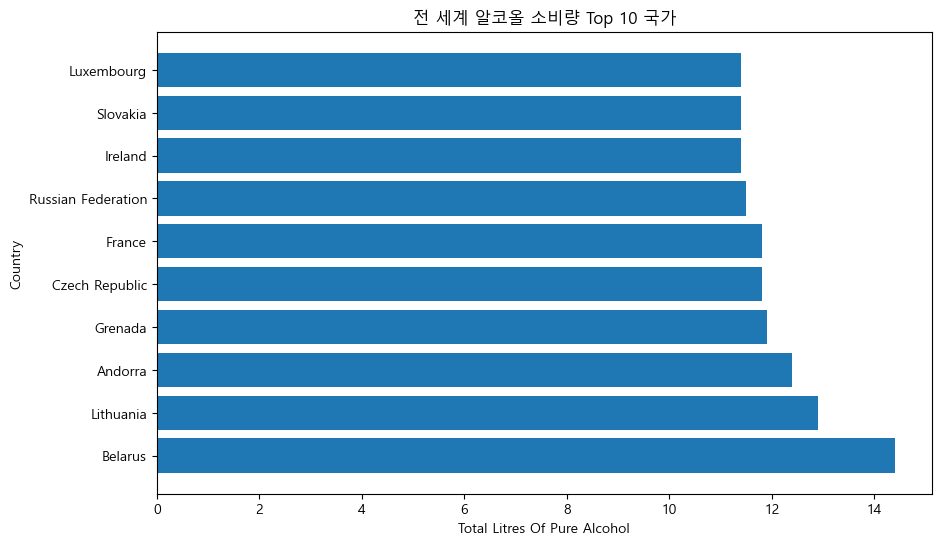

In [45]:
# 시각화
plt.figure(figsize = (10, 6))

plt.barh(drinks_top10["country"], drinks_top10["total_litres_of_pure_alcohol"])

plt.title("전 세계 알코올 소비량 Top 10 국가")
plt.xlabel("Total Litres Of Pure Alcohol")
plt.ylabel("Country")

plt.show()

#### 해석

1. 대체로 비슷하기는 하지만 Belarus가 주종 소비량이 가장 많습니다.
2. Top10 국가의 경우에는 기본적으로 10 Litres를 넘어가는 알코올 소비량을 보여주고 있습니다